# 04 — XGBoost

## Rôle de ce notebook

Entraîner et évaluer un modèle **XGBoost multi-classes** (gradient boosting sur arbres) sur les features CWRU (normal / ball / outerRace / innerRace), en réutilisant **exactement** les artefacts produits par `00_ml_setup_and_evaluation.ipynb` :

- les splits `data/splits/{train,val,test}.csv`
- le scaler `models/preprocessing/scaler.joblib` (rechargé, **jamais re-fit**)
- les fonctions de `src/evaluation/metrics.py` et `src/evaluation/plots.py`

⚠️ **Dépendance supplémentaire** : ce notebook utilise `src/models/xgb_wrapper.py` (nouveau module, à placer dans `src/models/` à la racine du projet, avec un `__init__.py` vide pour en faire un package). Il définit `XGBStringClassifier`, un wrapper sklearn-compatible qui permet à XGBoost de travailler avec des labels string natifs (comme tous les autres modèles du projet) au lieu des labels entiers qu'il attend nativement.

### Pipeline de ce notebook

```
1. Imports & config
2. Charger les splits (train/val/test)
3. Recharger le scaler et l'appliquer (transform uniquement)
4. Rappel de la baseline Dummy
5. Entraîner XGBoost (modèle par défaut + recherche d'hyperparamètres)
6. Évaluer sur train / val / test avec src.evaluation.metrics
7. Visualiser avec src.evaluation.plots (matrice de confusion, comparaison, importances)
8. Analyse des feature importances (interprétabilité)
9. Sauvegarder le modèle et les résultats
```

XGBoost est un modèle de **gradient boosting** : contrairement à Random Forest où les arbres sont indépendants (bagging), ici les arbres sont construits **séquentiellement**, chacun corrigeant les erreurs du précédent. C'est généralement le modèle le plus performant de cette série (Logistic Regression → SVM → Random Forest → XGBoost), mais aussi le plus sensible au sur-apprentissage si les hyperparamètres ne sont pas contrôlés (`max_depth`, `learning_rate`, régularisation).


## 1. Imports et configuration

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environnement prêt.")

Environnement prêt.


In [2]:
# --- Chemins (mêmes conventions que 00_ml_setup_and_evaluation.ipynb) ----
from pathlib import Path


PROJECT_ROOT = Path(r"C:\chadha Summer Internship\2nd\Predictive Maintenance")  # 02_machine_learning/ -> racine du projet

SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
SCALER_PATH  = PROJECT_ROOT / "models" / "preprocessing" / "scaler.joblib"
MODELS_DIR   = PROJECT_ROOT / "models" / "trained"
RESULTS_DIR  = PROJECT_ROOT / "results"
SRC_ROOT     = PROJECT_ROOT

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(SRC_ROOT))

from src.evaluation.metrics import (
    evaluate_model, get_confusion_matrix, get_classification_report,
    summarize_results, save_results_json
)
from src.evaluation.plots import (
    plot_confusion_matrix, plot_model_comparison,
    plot_class_distribution, plot_feature_importance
)
from src.models.xgb_wrapper import XGBStringClassifier

print(f"PROJECT_ROOT : {PROJECT_ROOT.resolve()}")
print(f"SPLITS_DIR   : {SPLITS_DIR}")
print(f"SCALER_PATH  : {SCALER_PATH}")
print(f"MODELS_DIR   : {MODELS_DIR}")
print(f"RESULTS_DIR  : {RESULTS_DIR}")
print("\nModules src.evaluation importés avec succès ✅")

PROJECT_ROOT : C:\chadha Summer Internship\2nd\Predictive Maintenance
SPLITS_DIR   : C:\chadha Summer Internship\2nd\Predictive Maintenance\data\splits
SCALER_PATH  : C:\chadha Summer Internship\2nd\Predictive Maintenance\models\preprocessing\scaler.joblib
MODELS_DIR   : C:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained
RESULTS_DIR  : C:\chadha Summer Internship\2nd\Predictive Maintenance\results

Modules src.evaluation importés avec succès ✅


## 2. Charger les splits (train / val / test)

On recharge les splits **exactement tels que sauvegardés** par le notebook 00 — aucun nouveau split n'est fait ici, pour garantir une comparaison équitable entre tous les modèles.

In [3]:
with open(SPLITS_DIR / "split_metadata.json") as f:
    split_meta = json.load(f)

label_col    = split_meta["label_col"]
group_col    = split_meta["group_col"]
feature_cols = split_meta["feature_cols"]

print(f"Label col    : {label_col}")
print(f"Group col    : {group_col}")
print(f"Nb features  : {len(feature_cols)}")

train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df   = pd.read_csv(SPLITS_DIR / "val.csv")
test_df  = pd.read_csv(SPLITS_DIR / "test.csv")

X_train, y_train = train_df[feature_cols], train_df[label_col]
X_val,   y_val   = val_df[feature_cols],   val_df[label_col]
X_test,  y_test  = test_df[feature_cols],  test_df[label_col]

print(f"\nTrain : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Label col    : label
Group col    : file_id
Nb features  : 12

Train : (3370, 12)
Val   : (946, 12)
Test  : (770, 12)


In [4]:
# --- Garde-fou : vérifier qu'aucun fichier source n'est partagé entre splits
set_train = set(train_df[group_col].unique())
set_val   = set(val_df[group_col].unique())
set_test  = set(test_df[group_col].unique())

assert set_train.isdisjoint(set_val),  "❌ Leakage train/val"
assert set_train.isdisjoint(set_test), "❌ Leakage train/test"
assert set_val.isdisjoint(set_test),   "❌ Leakage val/test"
print("✅ Splits toujours disjoints (pas de leakage).")

✅ Splits toujours disjoints (pas de leakage).


## 3. Recharger le scaler et l'appliquer

Le scaler a été **fit sur train dans le notebook 00** — ici on le recharge et on ne fait que `.transform()`, jamais `.fit()`, pour ne pas réintroduire de leakage.

Comme pour Random Forest, XGBoost (arbres de décision) n'a pas besoin de features standardisées, mais on applique tout de même le scaler pour rester **rigoureusement cohérent** avec le pipeline commun utilisé par tous les notebooks de modélisation.

In [5]:
scaler = joblib.load(SCALER_PATH)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)

print("Scaler rechargé et appliqué (transform uniquement) ✅")
print(f"Moyenne train (doit être ~0) : {X_train_scaled.mean().mean():.4f}")
print(f"Écart-type train (doit être ~1) : {X_train_scaled.std().mean():.4f}")

Scaler rechargé et appliqué (transform uniquement) ✅
Moyenne train (doit être ~0) : 0.0000
Écart-type train (doit être ~1) : 1.0001


## 4. Rappel de la baseline Dummy

Pour situer immédiatement les performances du modèle par rapport au plancher défini dans le notebook 00.

In [6]:
baseline_path = RESULTS_DIR / "baseline_dummy.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline_results = json.load(f)
    baseline_df = pd.DataFrame(baseline_results).T.round(4)
    print("=== Baseline Dummy (rappel, depuis notebook 00) ===")
    display(baseline_df)
else:
    print("⚠️  baseline_dummy.json introuvable — retourne au notebook 00.")

=== Baseline Dummy (rappel, depuis notebook 00) ===


,accuracy,f1_macro,precision_macro,recall_macro
most_frequent,0.1532,0.0664,0.0383,0.2500
stratified,0.2026,0.1965,0.2226,0.2375
uniform,0.2039,0.1976,0.2076,0.2092


## 5. Entraîner XGBoost

Deux étapes :
1. Un modèle par défaut, pour avoir un point de repère rapide
2. Une recherche d'hyperparamètres (`GridSearchCV`) avec un split **prédéfini train/val** (via `PredefinedSplit`), pour ne pas mélanger le val set dans une cross-validation classique et rester cohérent avec notre découpage par groupes

⚠️ `evaluate_model` (dans `src.evaluation.metrics`) attend un modèle dont `.predict()` retourne les **labels d'origine** (strings) — comme Logistic Regression, SVM et Random Forest. `XGBClassifier` attend nativement des labels entiers, donc on l'enveloppe dans `XGBStringClassifier` (défini dans `src/models/xgb_wrapper.py`) qui gère l'encodage/décodage en interne. Contrairement à une classe définie dans une cellule de notebook, ce wrapper vit dans un vrai module importable : il se recharge correctement une fois le modèle sauvegardé et rouvert dans `05_model_comparison.ipynb`, et il est pleinement compatible `GridSearchCV` / `permutation_importance` puisqu'il hérite de `BaseEstimator`.

In [7]:
# --- 5.1 Modèle par défaut -------------------------------------------------
xgb_default = XGBStringClassifier(
    estimator=XGBClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1,
    )
)
xgb_default.fit(X_train_scaled, y_train)  # y_train : labels string, gérés en interne

default_eval_val = evaluate_model(xgb_default, X_val_scaled, y_val, model_name="xgb_default_val")
print("=== XGBoost (défaut) — performance sur VAL ===")
print({k: v for k, v in default_eval_val.items() if k not in ("y_pred", "y_true")})

=== XGBoost (défaut) — performance sur VAL ===
{'model_name': 'xgb_default_val', 'accuracy': 0.7283298097251586, 'precision_macro': 0.7715004684381674, 'recall_macro': 0.7829391891891893, 'f1_macro': 0.7309631985998298}


In [8]:
# --- 5.2 Recherche d'hyperparamètres (GridSearchCV avec PredefinedSplit) --
# On combine train+val pour la recherche, mais PredefinedSplit garantit que
# GridSearchCV n'entraîne que sur train et n'évalue que sur val à chaque combinaison
# -> le test set reste totalement intouché.
# Les hyperparamètres de l'estimateur XGBoost interne se règlent via le préfixe
# standard sklearn "estimator__" (XGBStringClassifier expose son XGBClassifier
# interne sous l'attribut `estimator`).

X_trainval = pd.concat([X_train_scaled, X_val_scaled], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)  # toujours des labels string

# -1 = toujours dans le "train fold", 0 = utilisé comme fold de validation
test_fold = [-1] * len(X_train_scaled) + [0] * len(X_val_scaled)
ps = PredefinedSplit(test_fold=test_fold)

param_grid = {
    "estimator__n_estimators": [200, 400],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__subsample": [0.6, 0.8, 1.0],
    "estimator__colsample_bytree": [0.6, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=XGBStringClassifier(
        estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1)
    ),
    param_grid=param_grid,
    cv=ps,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_trainval, y_trainval)

print("\nMeilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur f1_macro (val) : {grid_search.best_score_:.4f}")

xgb_best = grid_search.best_estimator_

Fitting 1 folds for each of 108 candidates, totalling 108 fits

Meilleurs hyperparamètres : {'estimator__colsample_bytree': 0.8, 'estimator__learning_rate': 0.05, 'estimator__max_depth': 7, 'estimator__n_estimators': 200, 'estimator__subsample': 0.6}
Meilleur f1_macro (val) : 0.7505


In [9]:
# --- Comparaison rapide default vs tuned sur le VAL set -------------------
tuned_eval_val = evaluate_model(xgb_best, X_val_scaled, y_val, model_name="xgb_tuned_val")

comparison_val = summarize_results([default_eval_val, tuned_eval_val])
print("=== Comparaison default vs tuned (VAL set) ===")
display(comparison_val)

# On retient le meilleur modèle (par f1_macro sur val) comme modèle final
final_model = xgb_best if tuned_eval_val["f1_macro"] >= default_eval_val["f1_macro"] else xgb_default
final_model_name = "xgb_tuned" if final_model is xgb_best else "xgb_default"
print(f"\n✅ Modèle retenu : {final_model_name}")

=== Comparaison default vs tuned (VAL set) ===


,accuracy,precision_macro,recall_macro,f1_macro
model_name,,,,
xgb_default_val,0.7283,0.7715,0.7829,0.731
xgb_tuned_val,1.0000,1.0000,1.0000,1.000



✅ Modèle retenu : xgb_tuned


## 6. Évaluer sur train / val / test avec `src.evaluation.metrics`

On utilise les fonctions communes définies dans le notebook 00 pour garantir une évaluation identique à celle des autres modèles (Logistic Regression, SVM, Random Forest).

⚠️ Le test set n'est utilisé **qu'une seule fois ici**, pour l'évaluation finale — jamais pendant la recherche d'hyperparamètres.

In [10]:
eval_train = evaluate_model(final_model, X_train_scaled, y_train, model_name=f"{final_model_name}_train")
eval_val   = evaluate_model(final_model, X_val_scaled,   y_val,   model_name=f"{final_model_name}_val")
eval_test  = evaluate_model(final_model, X_test_scaled,  y_test,  model_name=f"{final_model_name}_test")

summary = summarize_results([eval_train, eval_val, eval_test])
print("=== XGBoost — résumé des performances ===")
display(summary)

# Sur/sous-apprentissage : écart train vs test
gap = eval_train["f1_macro"] - eval_test["f1_macro"]
print(f"\nÉcart f1_macro train - test : {gap:.4f}")
if gap > 0.1:
    print("⚠️  Écart important — possible surapprentissage (réduire max_depth / n_estimators ou augmenter la régularisation).")
else:
    print("✅ Écart raisonnable entre train et test.")

=== XGBoost — résumé des performances ===


,accuracy,precision_macro,recall_macro,f1_macro
model_name,,,,
xgb_tuned_train,1.0000,1.0000,1.0000,1.0000
xgb_tuned_val,1.0000,1.0000,1.0000,1.0000
xgb_tuned_test,0.6909,0.8329,0.7997,0.7073



Écart f1_macro train - test : 0.2927
⚠️  Écart important — possible surapprentissage (réduire max_depth / n_estimators ou augmenter la régularisation).


In [11]:
print("=== Classification report détaillé (TEST set) ===\n")
report = get_classification_report(eval_test["y_true"], eval_test["y_pred"])
report_df = pd.DataFrame(report).T.round(4)
display(report_df)

=== Classification report détaillé (TEST set) ===



,precision,recall,f1-score,support
Ball,0.3315,1.0000,0.4979,118.0000
InnerRace,1.0000,0.1987,0.3315,297.0000
Normal,1.0000,1.0000,1.0000,237.0000
OuterRace,1.0000,1.0000,1.0000,118.0000
accuracy,0.6909,0.6909,0.6909,0.6909
macro avg,0.8329,0.7997,0.7073,770.0000
weighted avg,0.8975,0.6909,0.6652,770.0000


## 7. Visualiser avec `src.evaluation.plots`

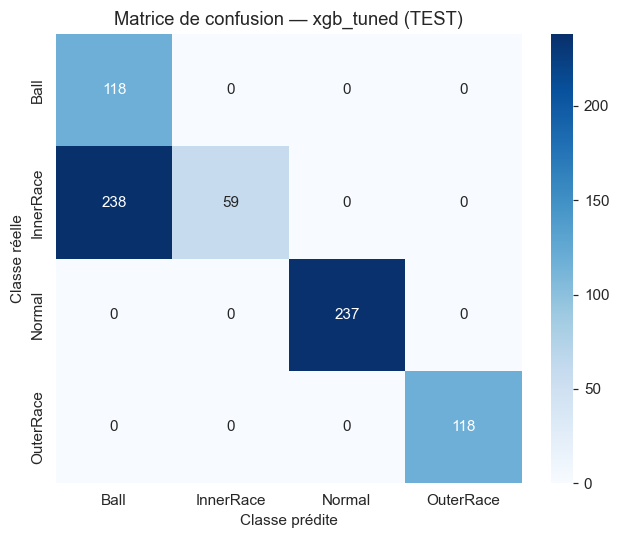

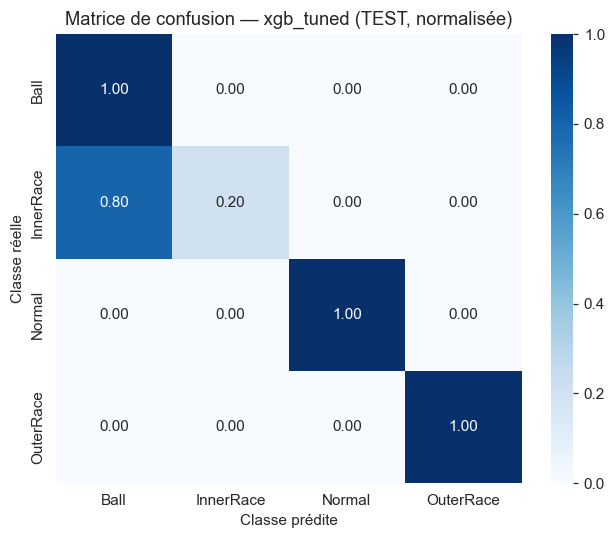

In [12]:
cm_test = get_confusion_matrix(eval_test["y_true"], eval_test["y_pred"])
plot_confusion_matrix(cm_test, model_name=f"{final_model_name} (TEST)")

cm_test_norm = get_confusion_matrix(eval_test["y_true"], eval_test["y_pred"])
plot_confusion_matrix(cm_test_norm, model_name=f"{final_model_name} (TEST, normalisée)", normalize=True)

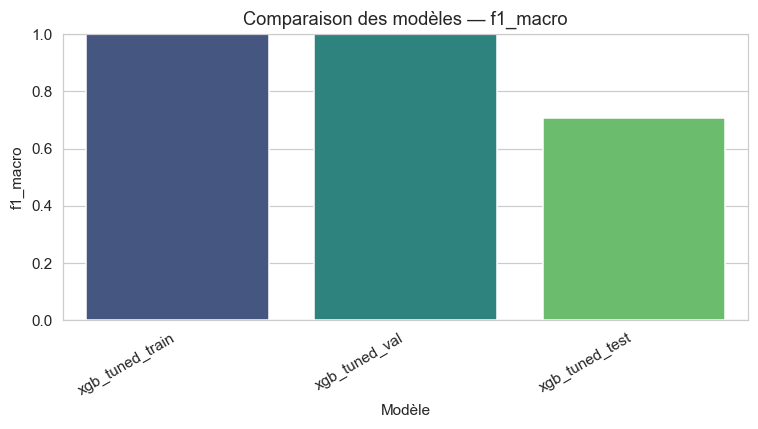

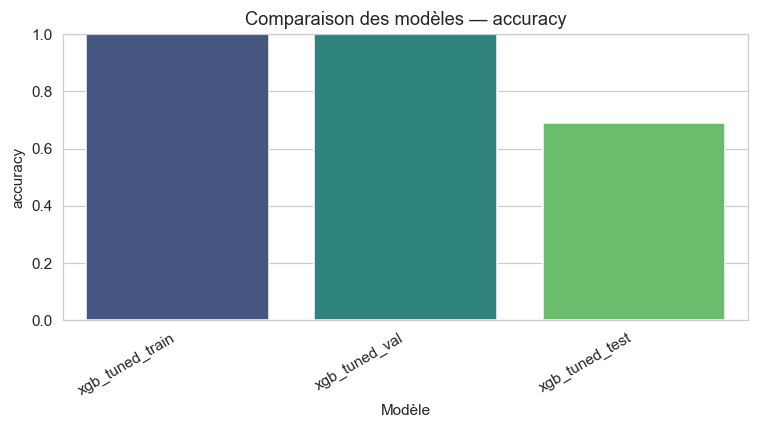

In [13]:
# Comparaison train/val/test sur les mêmes métriques (utile pour repérer l'overfitting)
plot_model_comparison(summary, metric="f1_macro")
plot_model_comparison(summary, metric="accuracy")

## 8. Analyse des feature importances (interprétabilité)

Comme Random Forest, XGBoost fournit une `feature_importances_` globale (par défaut basée sur le **gain moyen** apporté par chaque feature à chaque split où elle est utilisée). On complète avec une **permutation importance** sur le val set, plus fiable car elle mesure directement l'impact sur la métrique cible plutôt qu'une heuristique interne à l'algorithme d'entraînement.

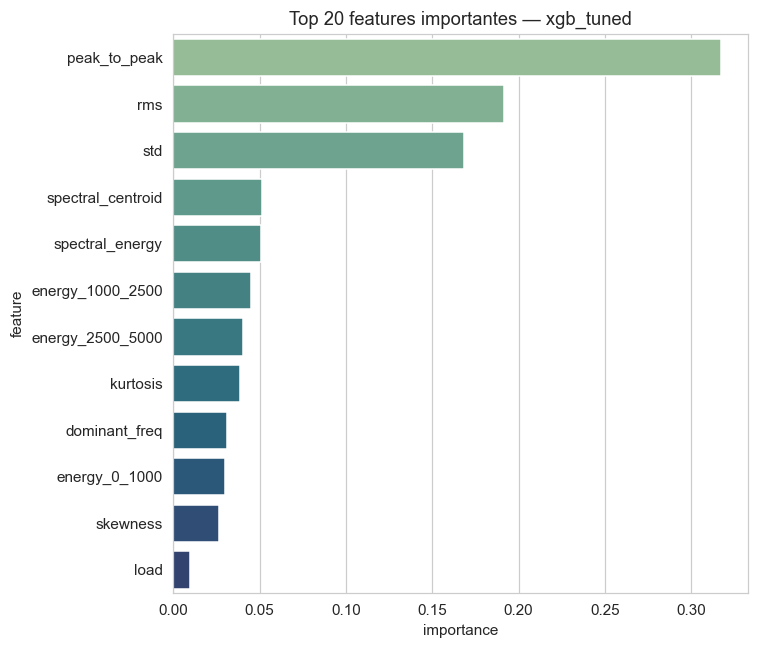

In [14]:
importances = final_model.feature_importances_

plot_feature_importance(
    importances=importances,
    feature_names=feature_cols,
    top_n=20,
    model_name=final_model_name
)

In [15]:
# Classement complet des features par importance (gain moyen)
importance_df = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("=== Classement complet des features (feature_importances_) ===\n")
print(importance_df.round(4))

=== Classement complet des features (feature_importances_) ===

peak_to_peak         0.3171
rms                  0.1916
std                  0.1683
spectral_centroid    0.0516
spectral_energy      0.0505
energy_1000_2500     0.0448
energy_2500_5000     0.0405
kurtosis             0.0385
dominant_freq        0.0312
energy_0_1000        0.0300
skewness             0.0263
load                 0.0098
dtype: float32


In [16]:
# Importance par permutation (complémentaire, moins biaisée) sur le VAL set
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_model, X_val_scaled, y_val,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro"
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("=== Top 10 features par importance de permutation (VAL, f1_macro) ===\n")
display(perm_df.head(10).round(4))

=== Top 10 features par importance de permutation (VAL, f1_macro) ===



,feature,importance_mean,importance_std
3,peak_to_peak,0.1714,0.0090
7,spectral_centroid,0.0979,0.0078
9,energy_1000_2500,0.0649,0.0053
10,energy_2500_5000,0.0348,0.0037
0,rms,0.0038,0.0015
5,dominant_freq,0.0038,0.0013
1,kurtosis,0.0014,0.0012
8,energy_0_1000,0.0010,0.0006
2,skewness,0.0000,0.0000
4,std,0.0000,0.0000


## 9. Sauvegarder le modèle et les résultats

Sauvegarde du modèle entraîné et de ses métriques, dans un format que `05_model_comparison.ipynb` pourra recharger pour comparer tous les modèles ensemble.

On sauvegarde directement `final_model` (le `XGBStringClassifier`, avec son `LabelEncoder` interne déjà fit) — pas besoin de fichier séparé pour les labels : au rechargement dans un autre notebook, `model.predict(X)` retournera directement des labels string, exactement comme pour Logistic Regression, SVM et Random Forest. C'est possible car `XGBStringClassifier` vit dans `src/models/xgb_wrapper.py`, un module importable (pas une classe de notebook), donc `joblib.load` sait le retrouver tant que `sys.path` contient `PROJECT_ROOT` (déjà fait par convention dans tous les notebooks).

In [17]:
model_path = MODELS_DIR / "xgboost.joblib"
joblib.dump(final_model, model_path)
print(f"Modèle sauvegardé : {model_path}")

save_results_json(eval_test, RESULTS_DIR / "xgb_test_results.json")
print(f"Résultats (test) sauvegardés : {RESULTS_DIR / 'xgb_test_results.json'}")

full_summary = {
    "model_name": final_model_name,
    "best_params": grid_search.best_params_,
    "train": {k: v for k, v in eval_train.items() if k not in ("y_pred", "y_true")},
    "val":   {k: v for k, v in eval_val.items()   if k not in ("y_pred", "y_true")},
    "test":  {k: v for k, v in eval_test.items()  if k not in ("y_pred", "y_true")},
}

with open(RESULTS_DIR / "xgb_full_summary.json", "w") as f:
    json.dump(full_summary, f, indent=2)

print(f"Résumé complet sauvegardé : {RESULTS_DIR / 'xgb_full_summary.json'}")

Modèle sauvegardé : C:\chadha Summer Internship\2nd\Predictive Maintenance\models\trained\xgboost.joblib
Résultats (test) sauvegardés : C:\chadha Summer Internship\2nd\Predictive Maintenance\results\xgb_test_results.json
Résumé complet sauvegardé : C:\chadha Summer Internship\2nd\Predictive Maintenance\results\xgb_full_summary.json


---

## Résumé — artefacts produits par ce notebook

| Artefact | Chemin |
|---|---|
| Modèle entraîné (labels string natifs, `XGBStringClassifier`) | `models/trained/xgboost.joblib` |
| Résultats test (format standard) | `results/xgb_test_results.json` |
| Résumé complet (train/val/test + hyperparamètres) | `results/xgb_full_summary.json` |

### Prochaine étape
➡️ `05_model_comparison.ipynb` — recharger les résumés (`*_full_summary.json`) et résultats test (`*_test_results.json`) de Logistic Regression, SVM, Random Forest et XGBoost, pour comparer tous les modèles côte à côte et sélectionner le meilleur.
